# Assignment 27 — GDP Data Visualization

## Topic Explanation

### What is GDP?
**Gross Domestic Product (GDP)** is the total monetary value of all goods and services produced within a country's borders in a given year. It's the most common measure of a country's economic size and is usually quoted in:
- **Billions of USD** (for medium economies)
- **Trillions of USD** (for large economies like USA, China)

GDP data is **time-series + cross-country** — perfect for visualization because we have:
- A continuous variable (Year) → trends
- Categorical groupings (Country) → comparisons
- Numeric measurements (GDP) → quantities to plot

### About the Dataset
The dataset contains GDP figures (in Billion USD) for **multiple countries** across **multiple years (2004–2026)**:

| Column | Meaning |
|--------|---------|
| `Country` | Country name (e.g., India, Belgium, Singapore) |
| `Year` | Calendar year |
| `GDP_Billion_USD` | Gross Domestic Product in billions of US dollars |

Note: figures from 2024 onward are usually IMF projections rather than actual realized values.

### What We'll Build (Four Tasks)

#### Task A — Bar Graph: Belgium's GDP 2006–2026
**Bar charts** are best for comparing values across discrete categories. Each bar = one year's GDP.

#### Task B — Pie Chart: 5 Countries' GDP in 2010
**Pie charts** show the parts of a whole. Each slice's size represents that country's share of the total. Best with ≤ 6 categories.

#### Task C — Line Chart: Bhutan vs Costa Rica
**Line charts** are best for comparing trends over time. Two lines on one chart let us see which country grew faster.

#### Task D — Scatter Plot: 4 Countries' GDP 2004–2026
**Scatter plots** show numeric data as discrete points. We'll use them as "circle views" — one circle per (country, year) data point, color-coded by country.

### Plot Selection Logic — When to Use Each

| Question | Best Plot | Why |
|----------|-----------|-----|
| How did X change over years? | Bar or Line | Years are sequential |
| What's each country's share of a total? | Pie | Parts of a whole |
| Which country grew faster? | Multi-line | Direct trend comparison |
| Are points clustered or scattered? | Scatter | Shows individual data points |

## Step 1: Import Libraries

In [1]:
# pandas — DataFrame operations, filtering, groupby
import pandas as pd

# numpy — numerical operations
import numpy as np

# matplotlib & seaborn — visualization
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load the Dataset

In [2]:
# read_csv() loads the CSV into a DataFrame
df = pd.read_csv('gdp.csv')
print("Shape:", df.shape)
df.head()

Shape: (276, 3)


,Country,Year,GDP_Billion_USD
0,Belgium,2004,474.86
1,Belgium,2005,493.04
2,Belgium,2006,499.98
3,Belgium,2007,563.80
4,Belgium,2008,568.31


In [3]:
# Inspect column types and check for missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          276 non-null    str    
 1   Year             276 non-null    int64  
 2   GDP_Billion_USD  276 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 6.6 KB


In [4]:
# What countries and years are in the dataset?
print(f"Countries ({df['Country'].nunique()}): {sorted(df['Country'].unique())}")
print(f"\nYears: {df['Year'].min()} – {df['Year'].max()}  ({df['Year'].nunique()} years)")

Countries (12): ['Algeria', 'Belgium', 'Bhutan', 'Costa Rica', 'Estonia', 'Fiji', 'India', 'Mexico', 'Nepal', 'Romania', 'Singapore', 'South Asia']

Years: 2004 – 2026  (23 years)


## Task A — Bar Graph: Belgium's GDP (2006–2026)

We filter the data to Belgium only, restrict the year range to 2006–2026, and plot a bar chart with one bar per year.

In [5]:
# Filter: rows where Country is Belgium AND Year is 2006-2026
belgium = df[(df['Country'] == 'Belgium') &
             (df['Year'] >= 2006) & (df['Year'] <= 2026)].sort_values('Year')

print(f"Belgium GDP records: {len(belgium)} years")
belgium.head()

Belgium GDP records: 21 years


,Country,Year,GDP_Billion_USD
2,Belgium,2006,499.98
3,Belgium,2007,563.80
4,Belgium,2008,568.31
5,Belgium,2009,638.36
6,Belgium,2010,579.06


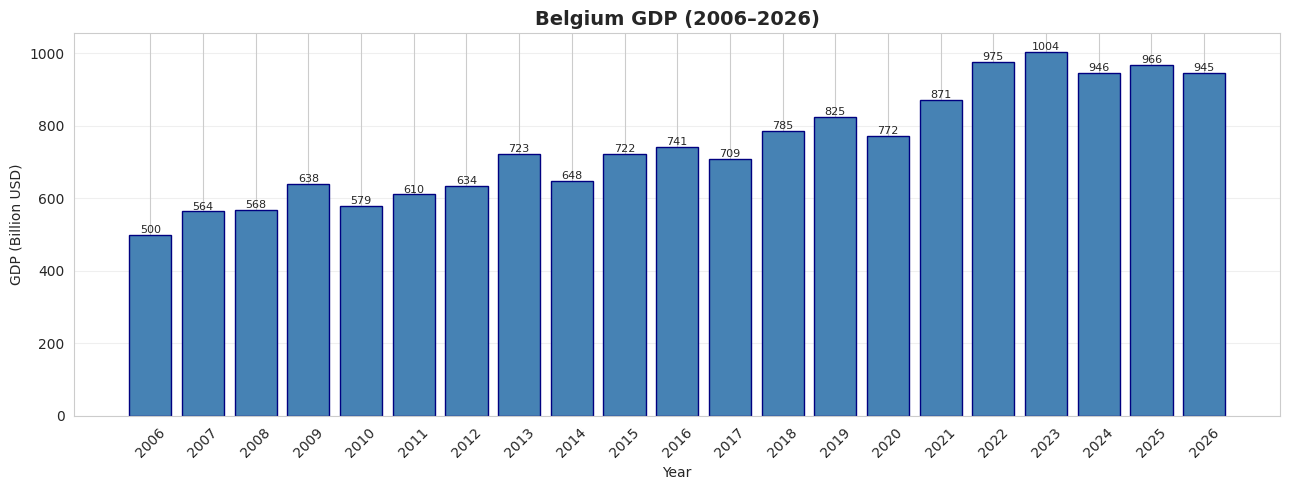

In [6]:
# Bar chart
plt.figure(figsize=(13, 5))
bars = plt.bar(belgium['Year'].astype(str), belgium['GDP_Billion_USD'],
               color='steelblue', edgecolor='navy')
plt.title('Belgium GDP (2006–2026)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('GDP (Billion USD)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Annotate each bar with its value
for bar, val in zip(bars, belgium['GDP_Billion_USD']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:.0f}', ha='center', fontsize=8, rotation=0)

plt.tight_layout()
plt.show()

## Task B — Pie Chart: 5 Countries' GDP in 2010

We filter for 2010 and the five countries: India, Nepal, Romania, South Asia, Singapore. Each slice represents the country's share of the combined total.

In [7]:
# Filter: Year=2010 AND Country in the list of five
countries_2010 = ['India', 'Nepal', 'Romania', 'South Asia', 'Singapore']
data_2010 = df[(df['Year'] == 2010) & (df['Country'].isin(countries_2010))]
print("GDP in 2010:")
data_2010

GDP in 2010:


,Country,Year,GDP_Billion_USD
29,India,2010,2726.79
52,Nepal,2010,40.21
75,Romania,2010,303.42
98,South Asia,2010,4592.89
121,Singapore,2010,480.27


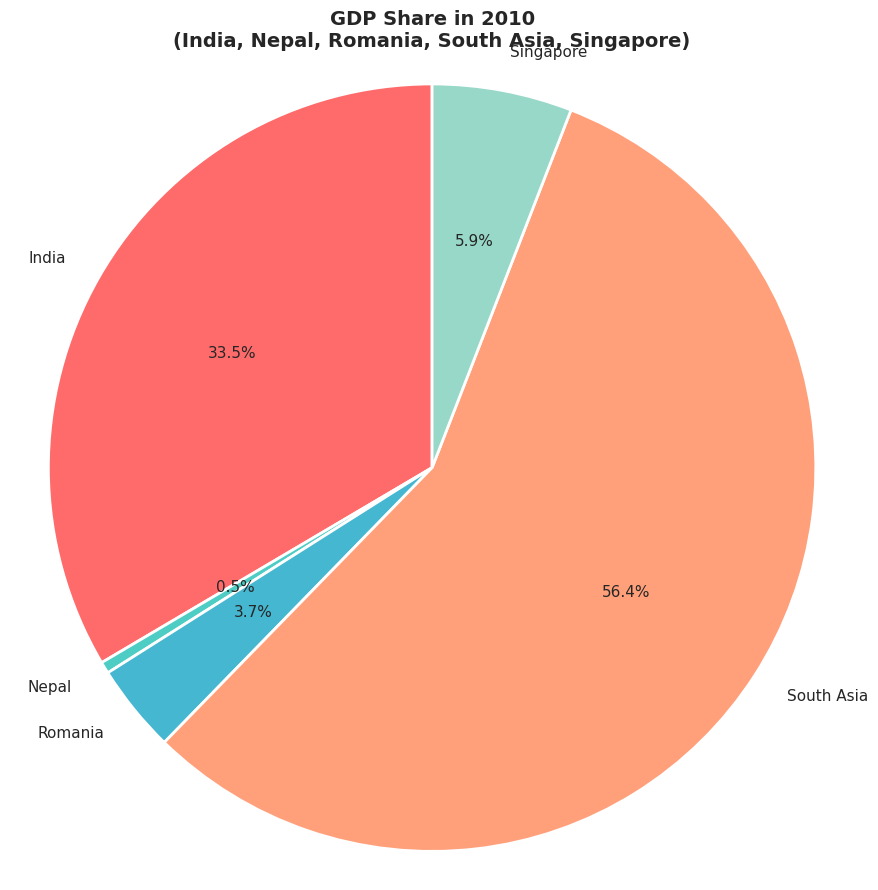


Total combined GDP: 8143.58 Billion USD
  India             2726.79  (33.48%)
  Nepal               40.21  ( 0.49%)
  Romania            303.42  ( 3.73%)
  South Asia        4592.89  (56.40%)
  Singapore          480.27  ( 5.90%)


In [8]:
# Pie chart
plt.figure(figsize=(9, 9))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

plt.pie(data_2010['GDP_Billion_USD'],
        labels=data_2010['Country'],
        autopct='%1.1f%%',                # show percentages on slices
        colors=colors,
        startangle=90,                     # start from 12 o'clock
        textprops={'fontsize': 11},
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

plt.title('GDP Share in 2010\n(India, Nepal, Romania, South Asia, Singapore)',
          fontsize=14, fontweight='bold')
plt.axis('equal')                          # circular pie
plt.tight_layout()
plt.show()

# Show actual values for context
total = data_2010['GDP_Billion_USD'].sum()
print(f"\nTotal combined GDP: {total:.2f} Billion USD")
for _, row in data_2010.iterrows():
    pct = row['GDP_Billion_USD'] / total * 100
    print(f"  {row['Country']:<14} {row['GDP_Billion_USD']:>10.2f}  ({pct:>5.2f}%)")

## Task C — Line Chart: Bhutan vs Costa Rica

A line chart with two lines lets us directly compare two countries' growth trajectories.

In [9]:
# Filter for both countries
two_countries = df[df['Country'].isin(['Bhutan', 'Costa Rica'])].sort_values(['Country', 'Year'])
print("Bhutan and Costa Rica GDP records:")
print(two_countries.head(10))

Bhutan and Costa Rica GDP records:
    Country  Year  GDP_Billion_USD
138  Bhutan  2004             2.68
139  Bhutan  2005             2.75
140  Bhutan  2006             2.59
141  Bhutan  2007             2.86
142  Bhutan  2008             3.29
143  Bhutan  2009             3.16
144  Bhutan  2010             3.53
145  Bhutan  2011             3.59
146  Bhutan  2012             3.62
147  Bhutan  2013             3.52


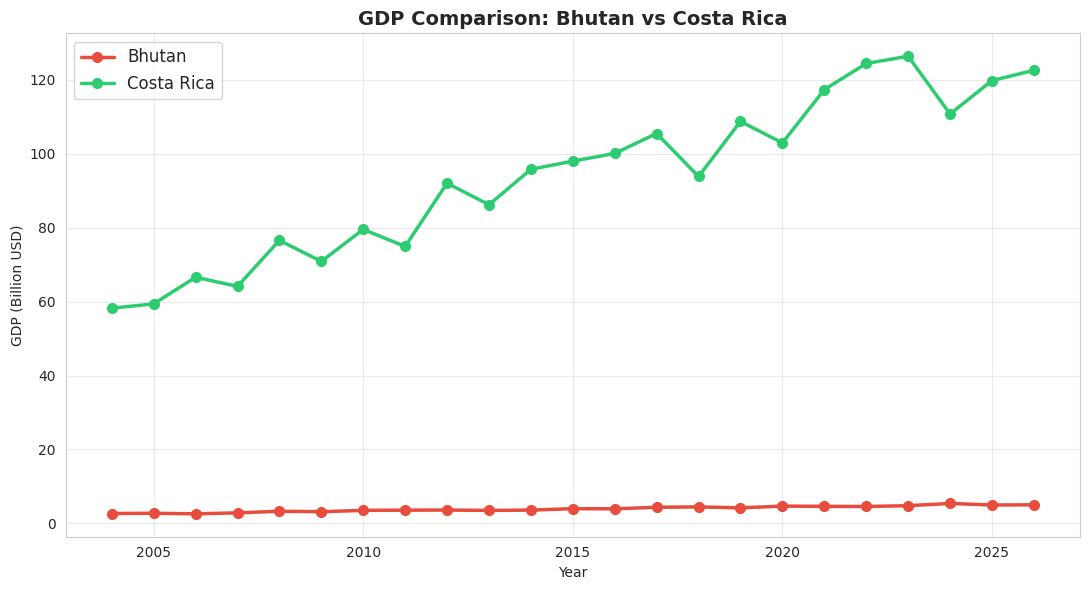

In [10]:
# Line chart — one line per country
plt.figure(figsize=(11, 6))

for country, color in [('Bhutan', '#E74C3C'), ('Costa Rica', '#2ECC71')]:
    sub = two_countries[two_countries['Country'] == country]
    plt.plot(sub['Year'], sub['GDP_Billion_USD'],
             marker='o', linewidth=2.5, label=country, color=color, markersize=7)

plt.title('GDP Comparison: Bhutan vs Costa Rica', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('GDP (Billion USD)')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [11]:
# Quick stats — confirm the magnitudes for the viva
print("Average GDP across all years:")
print(two_countries.groupby('Country')['GDP_Billion_USD'].mean().round(2))

print("\nGDP in 2024 (most recent observed year):")
recent = two_countries[two_countries['Year'] == 2024]
print(recent[['Country', 'GDP_Billion_USD']].to_string(index=False))

Average GDP across all years:
Country
Bhutan         3.92
Costa Rica    93.68
Name: GDP_Billion_USD, dtype: float64

GDP in 2024 (most recent observed year):
   Country  GDP_Billion_USD
    Bhutan             5.40
Costa Rica           110.76


## Task D — Scatter Plot: 4 Countries' GDP (2004–2026)

A scatter plot ("circle view") shows each (country, year) as a single point. Multiple countries can be color-coded for comparison.

In [12]:
# Filter for the four countries
four_countries = ['Mexico', 'Algeria', 'Fiji', 'Estonia']
data_four = df[df['Country'].isin(four_countries)].sort_values(['Country', 'Year'])
print(f"Records: {len(data_four)} (4 countries × {data_four['Year'].nunique()} years)")
data_four.head()

Records: 92 (4 countries × 23 years)


,Country,Year,GDP_Billion_USD
207,Algeria,2004,180.84
208,Algeria,2005,172.84
209,Algeria,2006,200.07
210,Algeria,2007,214.73
211,Algeria,2008,197.83


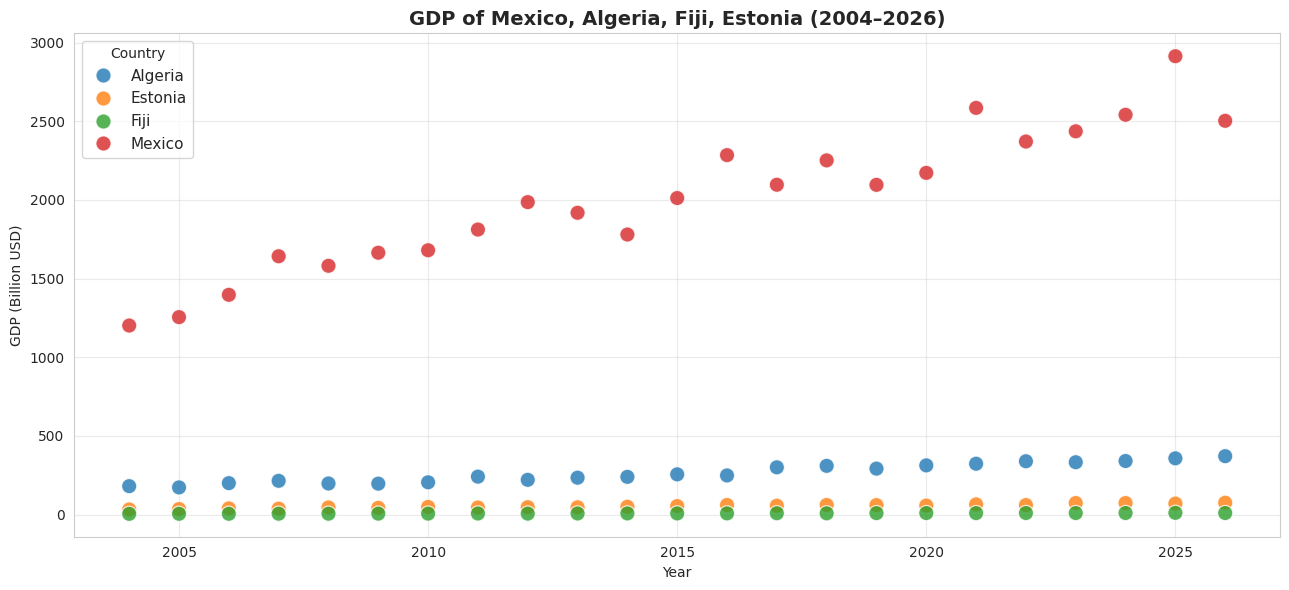

In [13]:
# Scatter plot — one color per country
plt.figure(figsize=(13, 6))
sns.scatterplot(data=data_four, x='Year', y='GDP_Billion_USD',
                hue='Country', s=120, palette='tab10', alpha=0.8)

plt.title('GDP of Mexico, Algeria, Fiji, Estonia (2004–2026)',
          fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('GDP (Billion USD)')
plt.legend(title='Country', fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

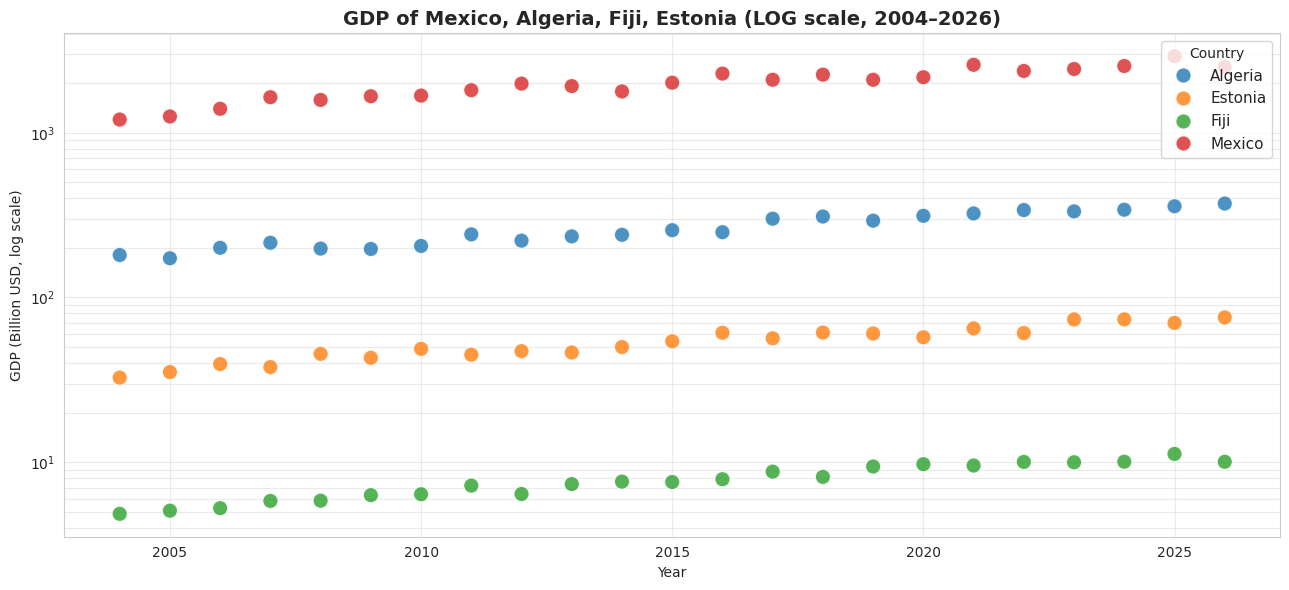

In [14]:
# Bonus: log scale Y-axis — Mexico's GDP is ~100x larger than Fiji's,
# which makes Fiji invisible on a linear scale
plt.figure(figsize=(13, 6))
sns.scatterplot(data=data_four, x='Year', y='GDP_Billion_USD',
                hue='Country', s=120, palette='tab10', alpha=0.8)
plt.yscale('log')
plt.title('GDP of Mexico, Algeria, Fiji, Estonia (LOG scale, 2004–2026)',
          fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('GDP (Billion USD, log scale)')
plt.legend(title='Country', fontsize=11)
plt.grid(True, alpha=0.4, which='both')
plt.tight_layout()
plt.show()

## Conclusion

We performed four GDP visualizations on the GDP dataset:

**Task A — Bar chart** of Belgium's GDP from 2006–2026: shows mostly upward growth with a dip around 2009 (financial crisis) and another around 2020 (COVID-19).

**Task B — Pie chart** of five economies in 2010: South Asia (a regional aggregate covering many countries) and India dominate the combined total. Singapore is much larger than Nepal despite Nepal's larger population — illustrating how GDP measures output rather than population.

**Task C — Line chart** of Bhutan vs Costa Rica: Costa Rica's economy is consistently and significantly larger than Bhutan's. Both grew over the period, but Costa Rica grew in absolute dollar terms more dramatically.

**Task D — Scatter plot** of Mexico, Algeria, Fiji, Estonia: Mexico's GDP dwarfs the others — about 100× larger than Fiji's. We added a bonus log-scale plot to make smaller economies visible.

**Big-picture insight:** GDP comparisons across countries of very different sizes are tricky on a linear scale. Either pick countries of similar size, or use a logarithmic axis when sizes vary by orders of magnitude.

**Plot selection takeaway:**
- **Bar chart** — comparing one entity across categories (years)
- **Pie chart** — parts of a whole at a single point in time
- **Line chart** — comparing trends across time
- **Scatter plot** — showing individual data points by category

## Explanation of Everything Used in This Notebook

### Libraries

| Library | Purpose |
|---------|---------|
| **pandas** | DataFrame operations, filtering with boolean masks |
| **numpy** | Numerical operations |
| **matplotlib.pyplot** | Base plotting (bar, pie, line, log scale) |
| **seaborn** | Cleaner scatter plots with `hue` for category coloring |

### Functions and Methods Used

#### Loading & Inspection
- `pd.read_csv(path)` — load CSV
- `df.shape`, `df.head()`, `df.info()`
- `df['col'].unique()`, `df['col'].nunique()` — distinct values
- `df['col'].min()`, `df['col'].max()` — range

#### Filtering
- `df[df['col'] == value]` — single-condition filter
- `df[(condition1) & (condition2)]` — AND filter (parentheses required!)
- `df['col'].isin(list)` — match against a list of values
- `df.sort_values('col')` — sort by a column

#### Aggregation
- `df.groupby('col')['target'].mean()` — group statistics
- `series.sum()` — total

#### Visualization

| Function | Purpose |
|----------|---------|
| `plt.bar(x, y, color)` | Vertical bar chart |
| `plt.pie(values, labels, autopct, colors)` | Pie chart |
| `plt.plot(x, y, marker, linewidth, label)` | Line chart |
| `sns.scatterplot(data, x, y, hue, s)` | Scatter plot with category colors |
| `plt.yscale('log')` | Logarithmic Y-axis |

#### Annotation & Layout
- `plt.title()`, `plt.xlabel()`, `plt.ylabel()` — text labels
- `plt.legend(fontsize=N)` — legend
- `plt.text(x, y, str)` — annotate specific points on a chart
- `plt.grid(True, alpha=0.4)` — gridlines
- `plt.xticks(rotation=45)` — rotate axis labels
- `plt.axis('equal')` — circular pie chart
- `plt.tight_layout()` — auto-spacing

### Pie Chart Parameters Explained

| Parameter | Meaning |
|-----------|---------|
| `autopct='%1.1f%%'` | Format string for percentage labels (1 decimal) |
| `startangle=90` | Where to start drawing (90 = 12 o'clock) |
| `colors=[...]` | Slice colors |
| `wedgeprops={...}` | Wedge styling (edge color, line width) |
| `textprops={...}` | Label text styling (font size, color) |
| `plt.axis('equal')` | Forces a circular shape |

### Key Concepts

#### Filtering with Boolean Masks
The pandas pattern: `df[df['col'] == value]` creates a boolean Series (True/False per row), then selects only the True rows.

For multiple conditions, **always use parentheses** around each condition:
```python
df[(df['Country'] == 'India') & (df['Year'] >= 2010)]
```

Without parentheses, Python's operator precedence breaks the logic.

#### `isin()` for Multiple Categories
Faster and cleaner than chaining `==` with `|`:
```python
# Slow / verbose
df[(df.Country == 'Mexico') | (df.Country == 'Algeria') | ...]
# Clean
df[df.Country.isin(['Mexico', 'Algeria', 'Fiji', 'Estonia'])]
```

#### Why Use Log Scale?
When values span multiple orders of magnitude (e.g., Mexico's $1.4T vs Fiji's $5B), a linear scale makes small values invisible. A log scale compresses the range so all values are readable.

#### Plot Selection Decision Tree
- Comparing **values across categories** (≤ 10 categories) → **Bar chart**
- Showing **parts of a whole** (≤ 6 categories) → **Pie chart**
- Comparing **trends over time** → **Line chart** (one line per group)
- Showing **individual data points** by category → **Scatter plot**
- Showing a **2D matrix of values** → **Heatmap**

## Viva Questions (with Answers)

### Conceptual

**Q1. What is GDP?**
Gross Domestic Product — the total monetary value of all goods and services produced within a country in a given period (usually a year).

**Q2. Why visualize GDP data?**
GDP changes are abstract numbers. Plotting them makes trends, comparisons, and proportions immediately visible.

### Plot Selection

**Q3. Why use a bar chart for Task A?**
Each year is a discrete category, and we're comparing one country's value across years. Bars make exact value comparison easy.

**Q4. Why use a pie chart for Task B?**
Pie charts show "parts of a whole" — each country's share of the combined GDP at one point in time. Best for ≤ 6 categories.

**Q5. Why use a line chart for Task C?**
Line charts highlight trends over time. Two countries on the same axes lets us directly compare growth rates.

**Q6. Why use a scatter plot for Task D?**
Scatter plots show each data point as an individual mark. With four countries × 23 years = 92 points, color-coded by country, we can see all values clearly.

### Pie Chart Specifics

**Q7. What does `autopct='%1.1f%%'` do?**
Formats the percentage label on each slice to 1 decimal place (e.g., "23.5%").

**Q8. What does `startangle=90` do?**
Starts the first slice at 12 o'clock (top of the pie) instead of 3 o'clock.

**Q9. What does `plt.axis('equal')` do?**
Forces a circular pie chart by making the X and Y axes equal length. Without it the pie may appear oval.

**Q10. When are pie charts a bad choice?**
- Too many categories (>6) — slices become hard to read
- Categories with similar values — angles look the same
- When showing a trend over time — use a line chart instead

### Filtering & Pandas

**Q11. How do you filter for multiple conditions?**
Combine with `&` (AND) or `|` (OR), with each condition in parentheses:
```python
df[(df['Country'] == 'India') & (df['Year'] >= 2010)]
```

**Q12. Why are parentheses required?**
Python evaluates `&` before comparison operators, so `df.col == val & df.col2 == val2` parses incorrectly. Parentheses force the right grouping.

**Q13. What does `.isin([...])` do?**
Returns True for rows where the column value is in the given list. Cleaner than chaining `==` with `|`.

**Q14. What does `.sort_values('col')` do?**
Sorts the DataFrame by a column. Often needed before plotting to ensure x-axis is in order.

### Scatter & Log Scale

**Q15. What's a "circle view" in Tableau-speak?**
A scatter plot where each data point is a circle. Same as `sns.scatterplot()` in matplotlib/seaborn.

**Q16. Why use a log scale?**
When values span multiple orders of magnitude, linear scale makes small values invisible. Log scale compresses the range proportionally.

**Q17. What does `plt.yscale('log')` do?**
Sets the y-axis to a logarithmic scale. Each major gridline represents a 10× difference.

**Q18. Why does Mexico dominate Task D?**
Mexico is a much larger economy (~$1.4T) than Algeria (~$200B), Estonia (~$30B), or Fiji (~$5B). Differences span orders of magnitude.

### Inferences

**Q19. Why does Belgium's GDP have a dip around 2009?**
Global financial crisis. Most developed economies declined that year.

**Q20. Why does Belgium's GDP have a dip around 2020?**
COVID-19 pandemic. Economic activity dropped due to lockdowns.

**Q21. What's the difference between "South Asia" and "India" in Task B?**
**South Asia** is a regional aggregate (India + Pakistan + Bangladesh + Nepal + Sri Lanka + Bhutan + Maldives). India is the dominant component.

**Q22. Are 2025–2026 figures actual or projected?**
Projected. GDP figures past the current year are usually IMF or World Bank forecasts.

### Code Specifics

**Q23. What does `palette='tab10'` mean?**
A color scheme — Matplotlib's "Tableau 10" palette, providing 10 visually distinct colors.

**Q24. What does `s=120` do in scatterplot?**
Sets marker size. Larger numbers = bigger circles.

**Q25. What's the difference between `marker='o'` and `markersize=7`?**
- `marker='o'` — selects the marker shape (circle)
- `markersize=7` — sets its size in points

**Q26. What does `alpha=0.8` do?**
Sets transparency (0 = invisible, 1 = opaque). Useful when many points overlap.

### Comparison & Extensions

**Q27. How would you visualize all countries on one plot?**
Use a small-multiples (faceted) approach — one subplot per country in a grid. Or pick top-N by latest GDP and only show those.

**Q28. How would you compare year-over-year growth rates instead of absolute GDP?**
Compute `df.groupby('Country')['GDP'].pct_change()` and plot the percentage change.

**Q29. What's the difference between Matplotlib's `plt.bar` and Seaborn's `sns.barplot`?**
- `plt.bar` — low-level, takes raw x and y arrays
- `sns.barplot` — higher-level, takes a DataFrame and category column, computes statistics if needed

**Q30. What other plots could show GDP data well?**
- **Stacked bar** — show each country's contribution to a total over years
- **Heatmap** — country × year matrix of GDP
- **Choropleth map** — color-code countries on a world map
- **Bubble chart** — scatter where bubble size = GDP, color = continent